# Análise Multivariada


## 1. Importação dos pacotes e funções

### 1.1 Bibliotecas utilizadas

In [1]:
import numpy as np
import scipy
import pandas as pd
import statsmodels.api as sm
from patsy import dmatrices 
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt
import matplotlib
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns

from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.cluster import KMeans

from math import sqrt


### 1.2 Configurações

In [2]:
pd.options.display.max_columns = None 
#pd.options.display.max_rows = None
seed = 42
np.random.seed(seed)

### 1.3 Funções

In [10]:
########################
###### Normalizador ####
########################


def normalizador_min_max(dados, variaveis):
    
    for j in variaveis:
        menor = min(dados[str(j)]) 
        maior = max(dados[str(j)])
        
        dif = maior - menor
        if dif==0:
            dif=1 
        
        for i in range(dados.shape[0]):
            dados.loc[i,j] = (dados[str(j)][i]-menor)/ dif

    return(dados) 


def normalizador_log(dados, variaveis):
    for j in variaveis:
        for i in range(dados.shape[0]):
            if pd.notnull(dados.loc[i, str(j)]) and dados.loc[i, str(j)] > 0:
                dados.loc[i, str(j)] = np.log(dados.loc[i, str(j)])
            else:
                dados.loc[i, str(j)] = np.log(1e-5)

    return dados 

In [16]:
def optimal_number_of_clusters(wcss):
    x1, y1 = 2, wcss[0]
    x2, y2 = 20, wcss[len(wcss)-1]

    distances = []
    for i in range(len(wcss)):
        x0 = i+2
        y0 = wcss[i]
        numerator = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1)
        denominator = sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(numerator/denominator)
    
    return distances.index(max(distances)) + 2

In [17]:
def calculate_wcss(data):
    wcss = []
    for n in range(2, 21):
        kmeans = KMeans(n_clusters=n)
        kmeans.fit(X=data)
        wcss.append(kmeans.inertia_)

    return wcss

## 2. Leitura dos Dados

In [3]:
df = pd.read_csv('coordenadas_mapeadas_variaveis.csv')

In [5]:
try:
    #del df['Unnamed: 0']
    del df['geometry']
    del df['index_right']
    del df['geom']
    del df['lat_ocr']
    del df['lon_ocr']
except:
    pass

In [6]:
print('A base possui', df.shape[0], 'linhas (coordenadas) e', df.shape[1], 'variáveis (atributos)')

A base possui 3135 linhas (coordenadas) e 52 variáveis (atributos)


In [7]:
df.head()

,n_coord,Altitude_numerica,Declividade_numerica,Orientacao_numerica,Curv_Vertical_numerica,Curv_Horizontal_numerica,Declividade_classes_A,Declividade_classes_B,Declividade_classes_C,Orientacao_octantes,Curv_Vertical_3classes,Curv_Vertical_5classes,Curv_Horizontal_3classes,Curv_Horizontal_5classes,Forma_de_terreno_classes,Relevo_sombreado_numerico,ADD_divisores_talvegues,Vegetacao_Natural_Dominante,Area_Antropica_Dominante,Floresta_Ombrofila_Densa,Formacao_Pioneira,Floresta_Ombrofila_Densa_Submontana,Influencia_urbana,legenda_2_Pecuária (pastagens),Vegetacao_Secundaria,Argilossolo,Gleissolo,Argilossolo_Vermelho_Amarelo,Gleissolo_Melanico,Area_Urbana,Unidades_de_Conservacao_Protecao_N_Integral,Unidades_de_Conservacao_Protecao_Integral,Sem_Plano_de_Menejo,Plano_de_Manejo,flg_comunidades,flg_agricola,flg_exploracao_mineral,flg_corpo_hidrico,flg_rocha,flg_cobertura_vegetal,flg_afloramento_rochoso,flg_favela,flg_ocupacao_desordenada,graurisc,flg_areas_de_risco,Acoes_DC_0,Acoes_DC_1,Acoes_DC_2,Acoes_DC_3,id_estacao,lat,long
0,0,69.984214,40.678449,186.517646,0.089928,0.303883,3.0,5.289048,4.289048,5.000000,3.000000,5.000000,3.0,5.0,9.000000,-0.000000,8.911721,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,522,-22.93495,-43.09957
1,1,36.737055,37.835880,153.154121,0.010433,0.334894,3.0,5.000000,4.000000,4.466879,2.171074,1.885711,3.0,5.0,8.171074,0.020821,7.411078,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,520,-22.93468,-43.07041
2,2,74.609010,29.264552,65.404156,0.095897,2.095171,3.0,5.000000,4.000000,2.711291,3.000000,5.000000,3.0,5.0,9.000000,0.715277,18.000000,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,520,-22.93468,-43.07041
3,3,29.972561,25.306148,41.485827,0.021861,0.992035,3.0,5.000000,4.000000,1.846789,2.398237,1.000000,3.0,5.0,8.398237,0.875118,15.395418,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,520,-22.93468,-43.07041
4,4,33.783319,34.557911,243.312805,0.019825,0.950413,3.0,5.000000,4.000000,6.538049,2.118183,1.194280,3.0,5.0,8.118183,0.272994,17.616969,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,509,-22.96146,-43.03310


In [8]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3135 entries, 0 to 3134
Data columns (total 52 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   n_coord                                      3135 non-null   int64  
 1   Altitude_numerica                            3135 non-null   float64
 2   Declividade_numerica                         3135 non-null   float64
 3   Orientacao_numerica                          3135 non-null   float64
 4   Curv_Vertical_numerica                       3135 non-null   float64
 5   Curv_Horizontal_numerica                     3135 non-null   float64
 6   Declividade_classes_A                        3135 non-null   float64
 7   Declividade_classes_B                        3135 non-null   float64
 8   Declividade_classes_C                        3135 non-null   float64
 9   Orientacao_octantes                          3135 non-null   float64
 10  

In [9]:
df.set_index('n_coord', inplace=True) # transformando n_coord em índice

In [11]:
normalizador_min_max(df,  ['Altitude_numerica'                            
,'Declividade_numerica'                         
,'Orientacao_numerica'                          
,'Curv_Vertical_numerica'                       
,'Curv_Horizontal_numerica'                     
,'Declividade_classes_A'                        
,'Declividade_classes_B'                        
,'Declividade_classes_C'                        
,'Orientacao_octantes'                          
,'Curv_Vertical_3classes'                       
,'Curv_Vertical_5classes'                       
,'Curv_Horizontal_3classes'                     
,'Curv_Horizontal_5classes'                     
,'Forma_de_terreno_classes'                     
,'Relevo_sombreado_numerico'                   
,'ADD_divisores_talvegues'                                          
,'graurisc'                                                                                                        
,'lat'                                          
,'long'])

,Altitude_numerica,Declividade_numerica,Orientacao_numerica,Curv_Vertical_numerica,Curv_Horizontal_numerica,Declividade_classes_A,Declividade_classes_B,Declividade_classes_C,Orientacao_octantes,Curv_Vertical_3classes,Curv_Vertical_5classes,Curv_Horizontal_3classes,Curv_Horizontal_5classes,Forma_de_terreno_classes,Relevo_sombreado_numerico,ADD_divisores_talvegues,Vegetacao_Natural_Dominante,Area_Antropica_Dominante,Floresta_Ombrofila_Densa,Formacao_Pioneira,Floresta_Ombrofila_Densa_Submontana,Influencia_urbana,legenda_2_Pecuária (pastagens),Vegetacao_Secundaria,Argilossolo,Gleissolo,Argilossolo_Vermelho_Amarelo,Gleissolo_Melanico,Area_Urbana,Unidades_de_Conservacao_Protecao_N_Integral,Unidades_de_Conservacao_Protecao_Integral,Sem_Plano_de_Menejo,Plano_de_Manejo,flg_comunidades,flg_agricola,flg_exploracao_mineral,flg_corpo_hidrico,flg_rocha,flg_cobertura_vegetal,flg_afloramento_rochoso,flg_favela,flg_ocupacao_desordenada,graurisc,flg_areas_de_risco,Acoes_DC_0,Acoes_DC_1,Acoes_DC_2,Acoes_DC_3,id_estacao,lat,long
n_coord,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.172138,0.217604,0.516144,0.606277,0.525204,0.666667,0.709113,0.657810,0.571429,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.465395,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,522,0.270676,0.188473
1,0.081971,0.201985,0.422701,0.430061,0.529465,0.666667,0.659971,0.600000,0.495268,0.585537,0.221428,1.000000,1.000000,0.896384,0.020825,0.377122,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,520,0.273433,0.395707
2,0.184681,0.154889,0.176934,0.619510,0.771365,0.666667,0.659971,0.600000,0.244470,1.000000,1.000000,1.000000,1.000000,1.000000,0.715431,1.000000,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,520,0.273433,0.395707
3,0.063625,0.133140,0.109945,0.455394,0.619770,0.666667,0.659971,0.600000,0.120970,0.699119,0.000000,1.000000,1.000000,0.924780,0.875307,0.846789,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,520,0.273433,0.395707
4,0.073960,0.183974,0.675214,0.450879,0.614051,0.666667,0.659971,0.600000,0.791150,0.559091,0.048570,1.000000,1.000000,0.889773,0.273053,0.977469,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,509,0.000000,0.660863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3130,0.374111,0.187439,0.743006,0.419621,0.501557,0.666667,0.659971,0.600000,0.853610,0.987636,1.000000,1.000000,1.000000,0.996909,0.466889,0.687277,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,526,0.656524,0.472674
3131,0.302234,0.112763,0.352941,0.431759,0.394825,0.666667,0.659971,0.600000,0.424345,1.000000,0.757396,0.014791,0.750000,0.261093,0.356448,0.313259,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0.6,1,0,0,1,0,524,0.869104,0.566342
3132,0.287362,0.093428,0.654074,0.436583,0.513019,0.666667,0.659971,0.448483,0.726910,1.000000,1.000000,0.334607,0.294696,0.500955,0.435102,0.593434,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0.0,0,0,0,0,0,508,0.556361,0.391443


In [12]:
df

,Altitude_numerica,Declividade_numerica,Orientacao_numerica,Curv_Vertical_numerica,Curv_Horizontal_numerica,Declividade_classes_A,Declividade_classes_B,Declividade_classes_C,Orientacao_octantes,Curv_Vertical_3classes,Curv_Vertical_5classes,Curv_Horizontal_3classes,Curv_Horizontal_5classes,Forma_de_terreno_classes,Relevo_sombreado_numerico,ADD_divisores_talvegues,Vegetacao_Natural_Dominante,Area_Antropica_Dominante,Floresta_Ombrofila_Densa,Formacao_Pioneira,Floresta_Ombrofila_Densa_Submontana,Influencia_urbana,legenda_2_Pecuária (pastagens),Vegetacao_Secundaria,Argilossolo,Gleissolo,Argilossolo_Vermelho_Amarelo,Gleissolo_Melanico,Area_Urbana,Unidades_de_Conservacao_Protecao_N_Integral,Unidades_de_Conservacao_Protecao_Integral,Sem_Plano_de_Menejo,Plano_de_Manejo,flg_comunidades,flg_agricola,flg_exploracao_mineral,flg_corpo_hidrico,flg_rocha,flg_cobertura_vegetal,flg_afloramento_rochoso,flg_favela,flg_ocupacao_desordenada,graurisc,flg_areas_de_risco,Acoes_DC_0,Acoes_DC_1,Acoes_DC_2,Acoes_DC_3,id_estacao,lat,long
n_coord,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.172138,0.217604,0.516144,0.606277,0.525204,0.666667,0.709113,0.657810,0.571429,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.465395,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,522,0.270676,0.188473
1,0.081971,0.201985,0.422701,0.430061,0.529465,0.666667,0.659971,0.600000,0.495268,0.585537,0.221428,1.000000,1.000000,0.896384,0.020825,0.377122,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,520,0.273433,0.395707
2,0.184681,0.154889,0.176934,0.619510,0.771365,0.666667,0.659971,0.600000,0.244470,1.000000,1.000000,1.000000,1.000000,1.000000,0.715431,1.000000,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,520,0.273433,0.395707
3,0.063625,0.133140,0.109945,0.455394,0.619770,0.666667,0.659971,0.600000,0.120970,0.699119,0.000000,1.000000,1.000000,0.924780,0.875307,0.846789,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,520,0.273433,0.395707
4,0.073960,0.183974,0.675214,0.450879,0.614051,0.666667,0.659971,0.600000,0.791150,0.559091,0.048570,1.000000,1.000000,0.889773,0.273053,0.977469,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,509,0.000000,0.660863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3130,0.374111,0.187439,0.743006,0.419621,0.501557,0.666667,0.659971,0.600000,0.853610,0.987636,1.000000,1.000000,1.000000,0.996909,0.466889,0.687277,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0.0,0,0,0,0,0,526,0.656524,0.472674
3131,0.302234,0.112763,0.352941,0.431759,0.394825,0.666667,0.659971,0.600000,0.424345,1.000000,0.757396,0.014791,0.750000,0.261093,0.356448,0.313259,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0.6,1,0,0,1,0,524,0.869104,0.566342
3132,0.287362,0.093428,0.654074,0.436583,0.513019,0.666667,0.659971,0.448483,0.726910,1.000000,1.000000,0.334607,0.294696,0.500955,0.435102,0.593434,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0.0,0,0,0,0,0,508,0.556361,0.391443


In [13]:
df = df.drop(['id_estacao'], axis=1)

# PCA

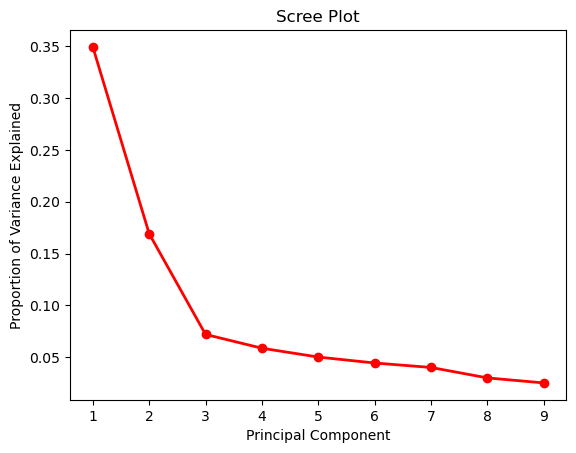

In [14]:
X = df
pca = PCA(n_components=9, svd_solver = 'auto',random_state = seed)
Principal_components=pca.fit_transform(X)
pca_df = pd.DataFrame(data = Principal_components,
                      #columns = ['PC 1', 'PC 2', 'PC 3', 'PC 4', 'PC 5', 'PC 6']
                     )
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.show()

O cotovelo ocorre com 3. 

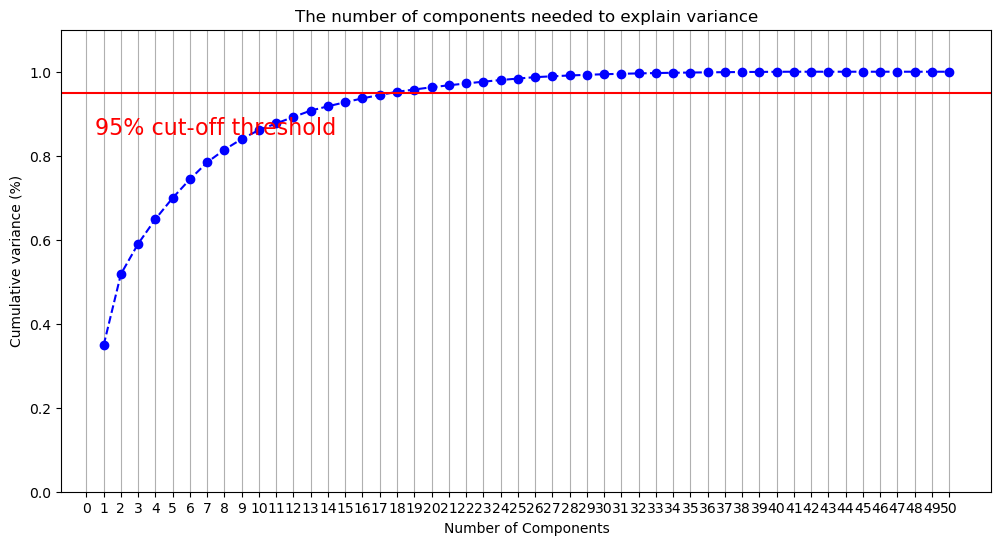

In [15]:
pca = PCA(n_components = 0.95)
pca.fit(X)
reduced = pca.transform(X)

pca = PCA(random_state = seed).fit(X)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12,6)

fig, ax = plt.subplots()
xi = np.arange(1, 51, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 51, step=1)) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)

ax.grid(axis='x')
plt.show()

In [20]:
sum_of_squares = calculate_wcss(df)

# calculando a quantidade ótima de clusters
n = optimal_number_of_clusters(sum_of_squares)

In [21]:
n

7

### Melhor PCA
ocorre com 17

In [ ]:
X = df
pca = PCA(n_components=17, svd_solver = 'auto',random_state = seed)
Principal_components=pca.fit_transform(X)
pca_df_atend = pd.DataFrame(data = Principal_components,
                      #columns = ['PC 1', 'PC 2', 'PC 3', 'PC 4', 'PC 5', 'PC 6']
                     )
components_atend = pca.components_.T
np.abs(components_atend.round(3))

In [ ]:
df.columns.tolist()

In [ ]:
pca_df_atend['n_coord'] = df.index
pca_df_atend.set_index('n_coord', inplace=True)
pca_df_atend

In [ ]:
X = df
n_comps = 17

methods = [
    ("PCA", PCA(random_state = seed)),
    ("Unrotated FA", FactorAnalysis(random_state = seed)),
    ("Varimax FA", FactorAnalysis(rotation="varimax",random_state = seed)),
]
fig, axes = plt.subplots(ncols=len(methods), figsize=(10, 8))

for ax, (method, fa) in zip(axes, methods):
    fa.set_params(n_components=n_comps)
    fa.fit(X)

    components = fa.components_.T
    print("\n\n %s :\n" % method)
    print(components)

    vmax = np.abs(components).max()
    ax.imshow(components, cmap="RdBu_r", vmax=vmax, vmin=-vmax)
    #ax.set_yticks(np.arange(len(feature_names)))
    #if ax.is_first_col():
   #     ax.set_yticklabels(feature_names)
   # else:
   #     ax.set_yticklabels([])
    ax.set_title(str(method))
    ax.set_xticks([0, 1,2,3])
    #ax.set_xticklabels(["Comp. 1", "Comp. 2"])
fig.suptitle("Factors")
plt.tight_layout()
plt.show()

# Kmeans 


## PCA 2 componentes

In [ ]:
df_PCA = pca_df_atend.copy()
data_per = pd.DataFrame()
data_avg = pd.DataFrame()
data_rate = pd.DataFrame()


for n_cluster in [3,4,5,6,7,8]:
    print('_______________________')
    print('________ k-means ______')
    print('______ ',n_cluster, 'Cluster _____')
    print('_______________________')
    km = KMeans(
        n_clusters=n_cluster,random_state=seed
    )
    y_km_at = km.fit_predict(df_PCA)
    atend_pca = df.copy()
    atend_pca['Cluster'] = y_km_at
    #atend_pca.reset_index(inplace = True)
    data_per = pd.concat([data_per,(100*atend_pca.groupby(['Cluster']).size()/len(atend_pca)).round(2) ])
    data_avg = pd.concat([data_avg,atend_pca.groupby(['Cluster']).mean().round(2) ])
    data_rate = pd.concat([data_rate,atend_pca.groupby(['Cluster']).mean().round(2).reset_index().rank(ascending = False)])
    print((100*atend_pca.groupby(['Cluster']).size()/len(atend_pca)).round(2))
    print(atend_pca.groupby(['Cluster']).mean().round(2))

In [ ]:
data_per

In [ ]:
data_avg

In [ ]:
data_rate.astype(int)

# Agrupamento de clusters

In [ ]:
km = KMeans(n_clusters=7,random_state=seed)
y_km_aten = km.fit_predict(pca_df_atend)

In [ ]:
df['Cluster']=y_km_aten+1
df['Cluster_desc'] = df['Cluster'].astype(str)

In [ ]:
df.groupby(['Cluster']).size()/ len(df)

In [ ]:
df = df.sort_values('Cluster')

In [ ]:
df

In [ ]:
pd.DataFrame(100*df.groupby(['Cluster']).size()/len(df)).reset_index().sort_values(0)

In [ ]:
plt.figure(figsize= (20,10))
sns.histplot(data = df, x = 'Cluster',  stat="percent", discrete=True, color = '#598D00' )

In [ ]:
plt.figure(figsize= (20,10))
sns.histplot(data = df, x = 'Cluster', hue = 'flg_cobertura_vegetal' ,  stat="percent", discrete=True, palette = 'mako' )

In [ ]:
df

In [ ]:
df['Cluster'].to_csv('coord_cluster_6.csv')

In [ ]:
df